# 2.4 - Fundamentals of Visualization Libraries (Part 2) - Seaborn

### Analysis questions guiding this notebook

- What are the most popular stations in the city?
- What are the busiest months and is there a weather component at play?
- What are the most popular trips between stations?
- Are the existing stations evenly distributed?

This notebook continues directly from the previous Matplotlib exercise, reusing the same merged
Citi Bike (New York City) trips + daily weather data set, for the year 2022.

**Note on environment:** this notebook is built and run on Kaggle, since the merged data set is a
single Parquet file larger than 900 MB and Kaggle provides enough RAM to comfortably work with it.

## 1. Imports and data

In [2]:
# Core libraries
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

# Show all columns when previewing the dataframe
pd.set_option('display.max_columns', None)

In [3]:
# Read the merged bike trips + weather data set produced in the previous (Matplotlib) exercise.
# It's stored as Parquet (rather than CSV) since the file is well over 900 MB, and Parquet is far
# more memory- and disk-efficient for a file this size.
df = pd.read_parquet('/kaggle/input/notebooks/danielabranca/citybike-merge-wrangle/citibike_merged_2022.parquet')

df.shape

(29838166, 15)

In [4]:
df.head()

,rideable_type,started_at,ended_at,start_station_name,end_station_name,start_lat,start_lng,end_lat,end_lng,member_casual,start_date,date,tavg,tmax,tmin
0,classic_bike,2022-01-13 21:36:47.689,2022-01-13 21:46:02.024,5 Ave & E 63 St,Broadway & W 51 St,40.766368,-73.971518,40.762288,-73.983362,member,2022-01-13,2022-01-13,4.5,8.0,1.0
1,classic_bike,2022-01-16 17:56:23.889,2022-01-16 18:03:50.269,Grand Army Plaza & Plaza St West,Bedford Ave & Montgomery St,40.672968,-73.970880,40.665816,-73.956934,member,2022-01-16,2022-01-16,-4.0,4.0,-12.0
2,electric_bike,2022-01-18 07:10:04.799,2022-01-18 07:20:54.450,W 20 St & 10 Ave,Broadway & W 51 St,40.745686,-74.005141,40.762288,-73.983362,member,2022-01-18,2022-01-18,1.0,3.0,-1.0
3,classic_bike,2022-01-22 12:10:10.225,2022-01-22 12:20:06.899,W 54 St & 9 Ave,10 Ave & W 28 St,40.765849,-73.986905,40.750664,-74.001768,member,2022-01-22,2022-01-22,-5.5,-1.0,-10.0
4,classic_bike,2022-01-08 16:35:16.497,2022-01-08 16:45:33.279,Sharon St & Olive St,Driggs Ave & Lorimer St,40.715353,-73.938560,40.721791,-73.950415,casual,2022-01-08,2022-01-08,-2.5,0.0,-5.0


In [5]:
df.dtypes

rideable_type                 object
started_at            datetime64[ns]
ended_at              datetime64[ns]
start_station_name            object
end_station_name              object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                 object
start_date            datetime64[ns]
date                  datetime64[ns]
tavg                         float64
tmax                         float64
tmin                         float64
dtype: object

Unlike the Chicago data set used in the reference exercise, this New York (Citi Bike) data set
doesn't include a `trip_id`, `birthyear`, or `gender` column. Instead, we have:

- `rideable_type` — the kind of bike used (`classic_bike`, `electric_bike`, `docked_bike`);
- `member_casual` — whether the rider is an annual `member` or a `casual` rider (pay-per-ride);
- `started_at` / `ended_at` — timestamps we can use to compute trip duration ourselves;
- `tavg`, `tmax`, `tmin` — daily average/max/min temperature, our weather variables.

We'll adapt every plot below to this column structure.

In [6]:
df.isnull().sum()

rideable_type             0
started_at                0
ended_at                  0
start_station_name       49
end_station_name      69884
start_lat                 0
start_lng                 0
end_lat               37223
end_lng               37223
member_casual             0
start_date                0
date                      0
tavg                      0
tmax                      0
tmin                      0
dtype: int64

### A bit more data preparation

We don't have an `age` variable here (no birth year in this data set), so that part of the
previous notebook is dropped entirely. What we do need is a **trip duration** column, which we
derive from `ended_at - started_at`, expressed in **minutes** — consistent with the unit used
throughout the rest of this portfolio (notebook 2.3).

In [7]:
# Trip duration in minutes, derived from the two timestamp columns
df['tripduration'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

df['tripduration'].describe().round(2)

count    29838166.00
mean           18.21
std           261.45
min           -57.29
25%             5.80
50%            10.16
75%            18.00
max        404481.01
Name: tripduration, dtype: float64

A number of trips have negative or implausibly long durations (e.g. a bike that wasn't properly docked).
- Lets use the same **IQR-based outlier rule** applied in notebook 2.3: anything above `Q3 + 1.5 * IQR` is treated as an outlier, and
negative durations are dropped outright; in other words, "too long to be a real trip".
- This is the same rule used in notebook 2.3, kept here for consistency across the portfolio.

In [8]:
Q1 = df['tripduration'].quantile(0.25)
Q3 = df['tripduration'].quantile(0.75)
IQR = Q3 - Q1
limit_max = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Maximum limit: {limit_max:.2f}")

Q1: 5.80
Q3: 18.00
IQR: 12.20
Maximum limit: 36.30


The max number given by the describe function is odd. Lets dig deeper into that:
- Inspecting the overall distribution of trip duration (in minutes). The huge gap between `the mean
(18.21)` and the `standard deviation (261.45)` is the first `red flag: a std this much larger than
the mean points to a heavily right-skewed distribution with extreme outliers pulling it up,
rather than to normal variability in how long people ride.`

In [9]:
above_limit = (df['tripduration'] > limit_max).sum()
below_zero = (df['tripduration'] < 0).sum()
total = len(df['tripduration'])

print(f"Above limit ({limit_max:.2f} min): {above_limit} ({above_limit/total*100:.2f}%)")
print(f"Negatives: {below_zero} ({below_zero/total*100:.2f}%)")

Above limit (36.30 min): 1883615 (6.31%)
Negatives: 357 (0.00%)


6% of the data rests as an outlier. It's a lot to be overlooked.
- 6% turned out to be far more than the ~1% an IQR rule typically flags on a roughly normal distribution - a sign this cutoff might be discarding real signal, not just noise, and worth investigating further before committing to it.

In [10]:
print(f"Skewness: {df['tripduration'].skew():.2f}")

Skewness: 592.18


Here we see that the data is `indeed` strongly right skewed.

In [11]:
tail = df[df['tripduration'] > limit_max]
print(tail['rideable_type'].value_counts(normalize=True))
print(tail['member_casual'].value_counts(normalize=True))

rideable_type
classic_bike     0.581758
electric_bike    0.418242
Name: proportion, dtype: float64
member_casual
member    0.535468
casual    0.464532
Name: proportion, dtype: float64


Looking at who's actually in that "above the limit" tail. If long trips are evenly spread across rider/bike types, the tail is likely just noise (clock errors, undocked bikes). If one group is overrepresented compared to its overall share of the data, the tail may instead reflect a real usage pattern worth keeping.


In [12]:
print("Baseline (all the dataset):")
print(df['rideable_type'].value_counts(normalize=True))
print()
print(df['member_casual'].value_counts(normalize=True))

Baseline (all the dataset):
rideable_type
classic_bike     0.606777
electric_bike    0.393223
Name: proportion, dtype: float64

member_casual
member    0.779455
casual    0.220545
Name: proportion, dtype: float64


Getting the same proportions for the full data set, to use as a baseline for comparison against the tail above. Without this baseline, the tail proportions on their own are not informative.

In [13]:
print(tail['tripduration'].describe().round(2))

count    1883615.00
mean         115.33
std         1035.28
min           36.30
25%           40.72
50%           47.59
75%           65.14
max       404481.01
Name: tripduration, dtype: float64


Describing the tail itself. The median (47.6 min) and Q3 (65.1 min) are still very plausible trip lengths, but the mean (115.3) and especially the huge standard deviation show the tail contains two different things: a majority of long-but-real trips, and a small number of extreme, almost certainly erroneous values (the max is over 400,000 minutes) dragging the average up.

- **Findings:** casual riders are more than twice as overrepresented in the long-trip tail (46.5%) compared to their overall share of the data (22.1%), while bike type shows no such pattern. This points to a real, casual-rider-driven behavior (longer, more exploratory rides) rather than pure noise. `The IQR cutoff at ~36 minutes would discard a lot of this genuine signal.`
- A hard cutoff at 24 hours is tested below instead, to isolate only the values that are almost certainly system errors (e.g. a bike never properly docked).

In [14]:
#"technical" cut:anything above this is much probably an error, not a real trip
hard_limit = 24 * 60  # 1440 minutes = 24 hours

extreme = df[df['tripduration'] > hard_limit]
print(f"Trips above 24h: {len(extreme)} ({len(extreme)/len(df)*100:.3f}%)")

Trips above 24h: 39772 (0.133%)


Instead of the statistical IQR cutoff, applying a hard, common-sense limit: 
- any trip lasting more than 24 hours is almost certainly a system error (e.g. a bike that was never docked), not a real ride. Checking how many trips this affects shows it removes a tiny fraction of the data (0.133%) far less than the IQR rule's 6% - while preserving the genuine long-trip behavior of casual riders found above.

In [15]:
df = df[(df['tripduration'] > 0) & (df['tripduration'] <= hard_limit)]
df['tripduration'].describe().round(2)

count    29798037.00
mean           15.49
std            33.27
min             0.15
25%             5.79
50%            10.15
75%            17.95
max          1439.95
Name: tripduration, dtype: float64

**Findings:**

- After applying the 24h hard limit, the distribution looks much healthier: the mean (15.49) and
standard deviation (33.27) are now in a sane relationship to each other, instead of the std being
14x the mean as before. The max (1,439.95 minutes ≈ 24h) confirms the cutoff is working exactly as
intended, and only about 40,000 trips were removed out of nearly 29.8 million — a tiny fraction
compared to the 6% the IQR rule would have discarded, while keeping the genuine long trips from
casual riders identified above.

## 2. Setting a theme: style and palette

For this notebook I chose:

- **Style: `whitegrid`** — a white background with subtle gridlines. It keeps the focus on the
  data itself (bars, lines, points) rather than on the background, while the gridlines still help
  read values on the axes accurately — important since we'll be comparing trip counts,
  temperatures, and trip durations.
- **Palette: `"viridis"`** — a sequential, perceptually uniform palette that's also colorblind-safe.
  It works well both for continuous/ordered variables and for a moderate number of categories.

We'll apply this globally with `sns.set_theme()`, which sets the style and palette for every plot
that follows, unless explicitly overridden for a specific plot (as we'll do in Step 3).

In [16]:
sns.set_theme(style="whitegrid", palette="viridis")

## 3. Bar chart - top 20 starting stations

To answer "what are the most popular stations in the city?", we count the number of trips per
starting station (`start_station_name`) and select the 20 stations with the most trips.

In [17]:
# Count trips per starting station. value_counts() is more memory-friendly than a groupby here,
# which matters given the size of this data set.
station_counts = df['start_station_name'].value_counts().reset_index()
station_counts.columns = ['start_station_name', 'trip_count']

# Keep only the top 20
top20 = station_counts.nlargest(20, 'trip_count')
top20.head()

,start_station_name,trip_count
0,W 21 St & 6 Ave,128899
1,West St & Chambers St,123130
2,Broadway & W 58 St,114178
3,6 Ave & W 33 St,106321
4,1 Ave & E 68 St,104770


or I could have written it this way:
````python
station_counts = df.groupby('start_station_name')['trip_id'].count().reset_index()
station_counts.columns = ['start_station_name', 'trip_count']

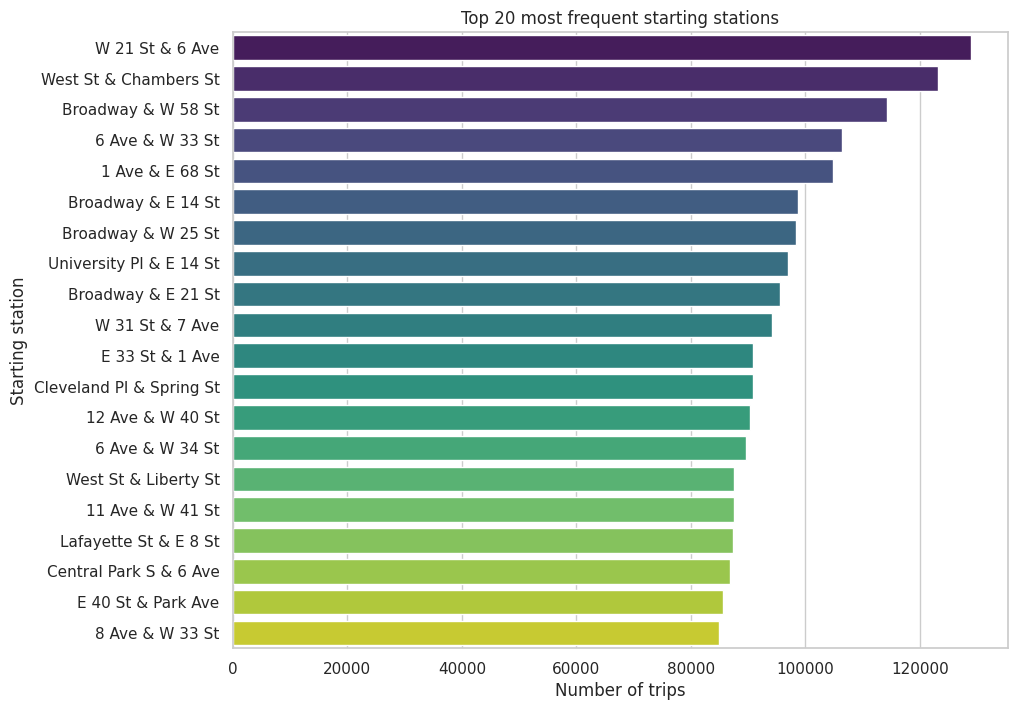

In [18]:
plt.figure(figsize=(10, 8))
sns.barplot(data=top20, x='trip_count', y='start_station_name', hue='start_station_name',
            palette='viridis', legend=False)
plt.title('Top 20 most frequent starting stations')
plt.xlabel('Number of trips')
plt.ylabel('Starting station')
plt.show()

**Does the theme's palette (`viridis`) make sense here?**

Not entirely, for two reasons:

1. `viridis` is a **sequential** palette, designed to show a progression of values (e.g. low to
   high). Here, each bar represents a different station — a **categorical** variable with no
   inherent order — so the color gradient of `viridis` doesn't communicate any useful extra
   information, and could even (wrongly) suggest there's a hierarchy or progression between
   stations.
2. More importantly: the default palette has few distinct colors automatically generated when
   there are many categories (20 stations). Without explicitly specifying `n_colors`, seaborn may
   repeat or poorly sample the gradient, resulting in bars with very similar colors that are hard
   to tell apart.

For this specific plot, we temporarily switch to a palette better suited to 20 distinct
categories, without affecting the global theme set in Step 2.

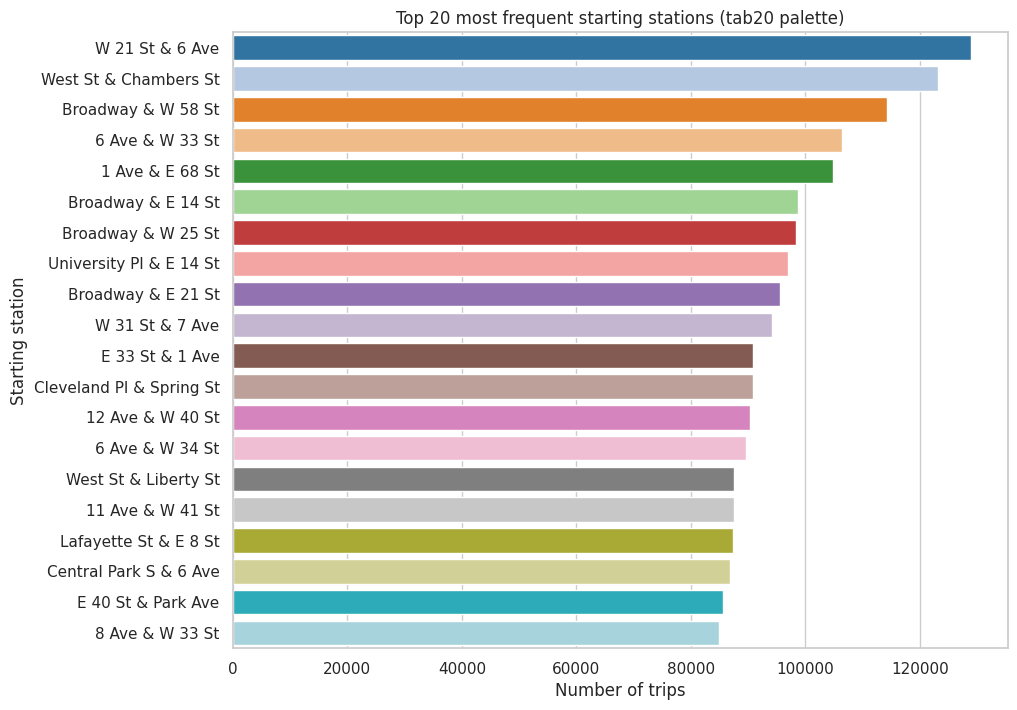

In [19]:
plt.figure(figsize=(10, 8))
# Temporarily override the palette just for this plot, asking explicitly for 20 distinct colors
with sns.color_palette('tab20', n_colors=20):
    ax = sns.barplot(data=top20, x='trip_count', y='start_station_name',
                      hue='start_station_name', palette='tab20', legend=False)
    ax.set_title('Top 20 most frequent starting stations (tab20 palette)')
    ax.set_xlabel('Number of trips')
    ax.set_ylabel('Starting station')
plt.show()

With `tab20` (a **qualitative** palette, purpose-built for up to 20 distinct categories), each
station gets a clearly different color from its neighbors, making the chart easier to read —
without having to abandon the global theme, which still applies to every other plot in this
notebook.

## 4. Dual-axis line plot (bike trips vs. temperature) with seaborn

This recreates, in seaborn, the dual-axis plot built in Matplotlib in the previous exercise:
daily bike trip counts vs. average daily temperature throughout 2022.

In [20]:
# Aggregate the number of trips per day. Using 'date' (already present in the data set, at
# daily resolution) rather than 'started_at' avoids creating an extra column just for grouping.
df_daily_counts = df.groupby('date').size().reset_index(name='bike_rides_daily')

# Bring in the daily weather (one row per day, since tavg/tmax/tmin only vary by date, not by trip)
df_daily_weather = df[['date', 'tavg']].drop_duplicates(subset='date')

df_daily = df_daily_counts.merge(df_daily_weather, on='date', how='left').set_index('date')
df_daily.head()

,bike_rides_daily,tavg
date,,
2022-01-01,20289,12.0
2022-01-02,42538,10.0
2022-01-03,32550,0.0
2022-01-04,35936,-2.0
2022-01-05,33739,4.5


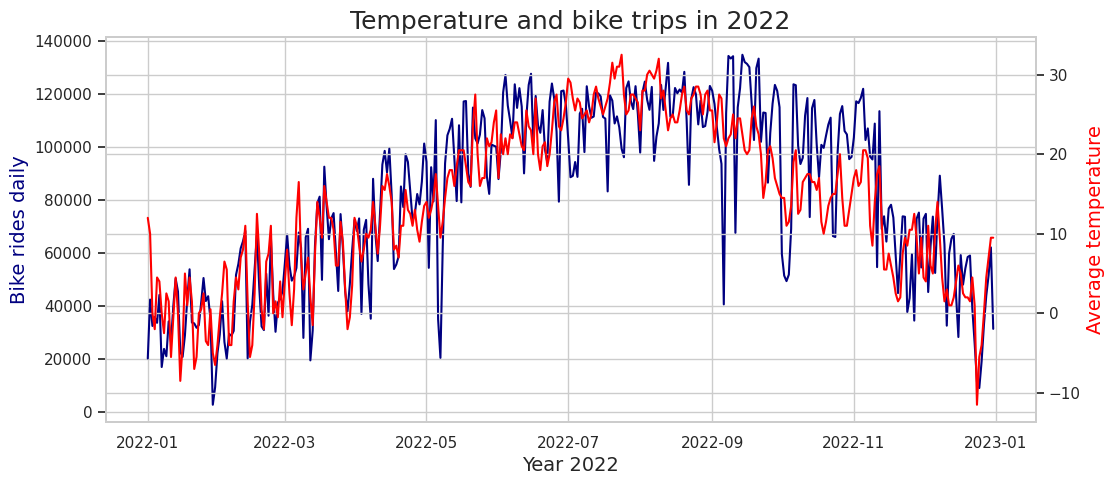

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=df_daily, x=df_daily.index, y='bike_rides_daily', color='navy', ax=ax)
ax.set_xlabel('Year 2022', fontsize=14)
ax.set_ylabel('Bike rides daily', color='navy', fontsize=14)

ax2 = ax.twinx()
sns.lineplot(data=df_daily, x=df_daily.index, y='tavg', color='red', ax=ax2)
ax2.set_ylabel('Average temperature', color='red', fontsize=14)

plt.title('Temperature and bike trips in 2022', fontsize=18)
plt.show()

Just like in the Matplotlib version, the pattern is clear: the number of daily trips closely
tracks the average temperature, rising in the warmer months and dropping in winter — a strong
indication that demand does have a seasonal/weather-related component.

## 5. Box plot

This data set doesn't include rider demographics like age or gender, so instead we look at the
distribution of **trip duration** (`tripduration`) by **rider type** (`member_casual`) — the
closest categorical equivalent available, and arguably more directly useful for the business
questions at hand (does an annual member ride differently than a casual, pay-per-ride user?).

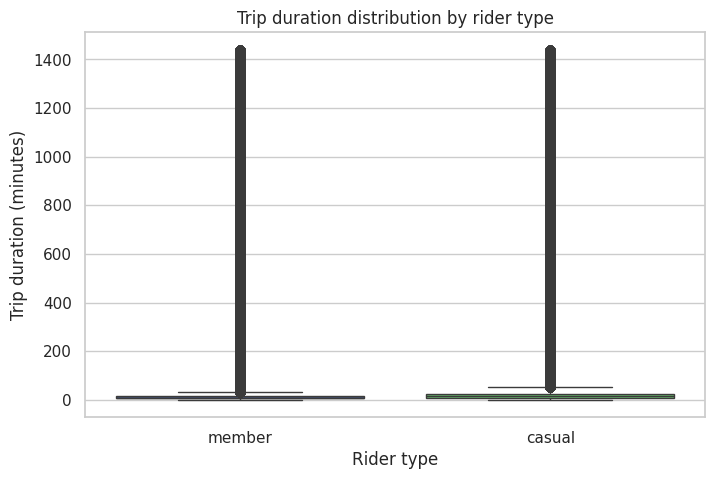

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='member_casual', y='tripduration', data=df, hue='member_casual',
            palette={'member': '#3b528b', 'casual': '#5dc963'}, legend=False)
plt.title('Trip duration distribution by rider type')
plt.xlabel('Rider type')
plt.ylabel('Trip duration (minutes)')
plt.show()

**Box plot analysis:**

The box for each group (member/casual) represents the interquartile range (IQR) — i.e. where the
middle 50% of trip durations are concentrated for that group — and the line inside the box marks
the median trip duration. Casual riders typically show a noticeably higher median and a taller box
than members, suggesting their trips tend to run longer and be more variable in length, which fits
a leisure/tourism use case rather than a quick commute. Members, by contrast, tend to have a
lower, more tightly packed box, consistent with short, predictable, point-to-point rides. The
whiskers show how far the data extends before being flagged as an outlier, and the points beyond
them represent unusually long trips within each group — likely riders who took a longer detour or
forgot to dock the bike promptly. Overall, this plot suggests that membership pricing and station
placement strategies could reasonably be tailored differently for members versus casual riders.

## 6. FacetGrid

One of the project's analysis questions is whether trip patterns vary across rider types and
bike types. A `FacetGrid` is ideal here: it lets us compare the distribution of `tripduration` side
by side, split by `member_casual` (rows) and `rideable_type` (columns), without cramming everything
into a single, unreadable chart. The data set has already been filtered to remove only the clearly
erroneous trips (using the 24h hard limit decided on above), so the genuine long trips from casual
riders are still part of this comparison.

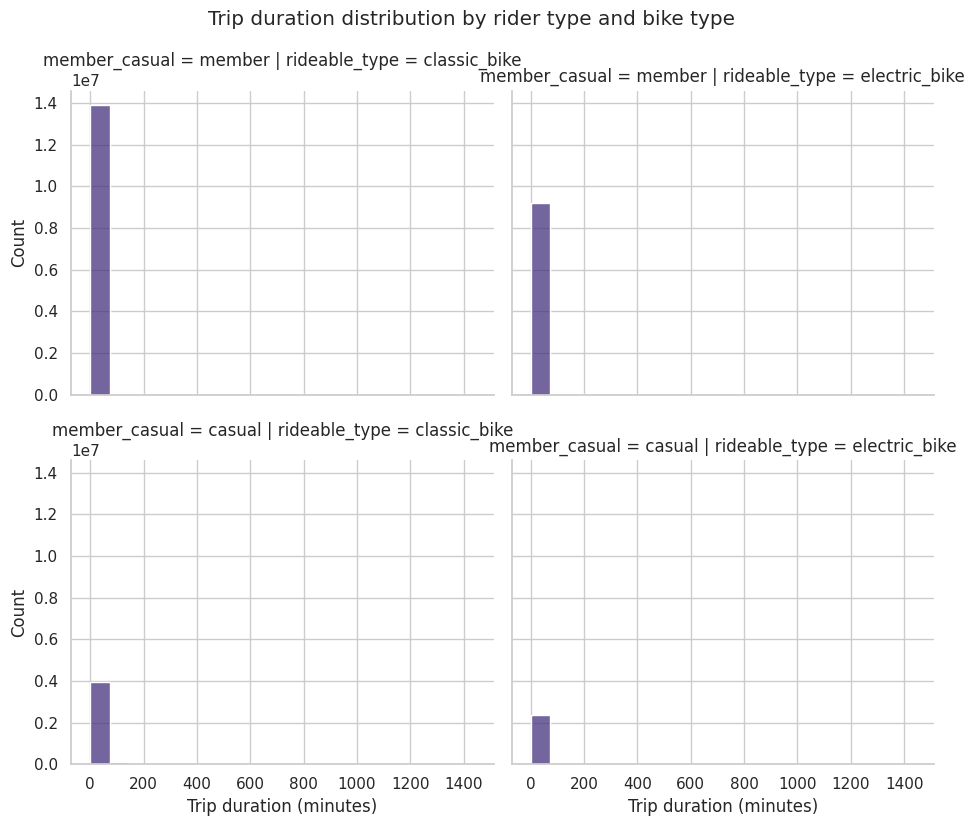

In [23]:
grid = sns.FacetGrid(df, col='rideable_type', row='member_casual', height=4, aspect=1.2)
grid.map(sns.histplot, 'tripduration', bins=20)
grid.set_axis_labels('Trip duration (minutes)', 'Count')
grid.figure.suptitle('Trip duration distribution by rider type and bike type', y=1.03)
plt.show()

**Analysis:** The `FacetGrid` makes it possible to compare, in a single view, the shape of the
`tripduration` distribution across every combination of `member_casual` and `rideable_type`. If
casual riders on classic or docked bikes show a wider, more right-skewed distribution than members
on the same bike type, that reinforces the leisure-vs-commute distinction seen in the box plot
above. Comparing `electric_bike` against `classic_bike` within the same rider type also reveals
whether electric bikes tend to shorten trips (since they're faster to cover the same distance) —
useful for deciding how to size and distribute the electric fleet across stations and rider
segments.

## 7. Next steps: saving and pushing to the remote repository

In [24]:
# Save the (slightly enriched) data set back to disk, in case the new tripduration column is
# useful downstream. Parquet is used again here, since the file is far too large for CSV to be
# practical, both in terms of disk space and read/write speed.
df.to_parquet('nyc_bike_weather_2022_enriched.parquet')

**Before `git push`:**

1. Temporarily remove the data file (the Parquet file, and any other file >25 MB) from the project
   folder before committing/pushing — e.g. by moving it out with `mv` or adding it to
   `.gitignore`. This matters even more here, since the raw file is over 900 MB.
2. Commit and push only the notebook and other code files:
   ```bash
   git add .
   git commit -m "Add Seaborn visualizations (E4) - NYC Citi Bike data"
   git push origin main
   ```